In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv('linear regression dataset.csv')

In [3]:
df.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


In [4]:
df.isnull().sum()

,0
x,0
y,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       700 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 11.1 KB


In [9]:
df.dropna(subset='y',inplace=True)

In [10]:
df.isnull().sum()

,0
x,0
y,0


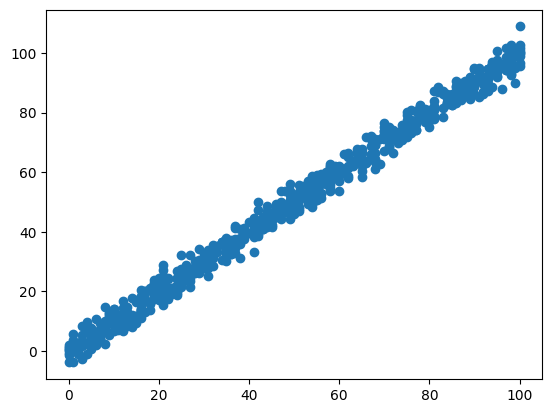

In [11]:
plt.scatter(df['x'],df['y'])

In [12]:
df.corr()

,x,y
x,1.00000,0.99534
y,0.99534,1.00000


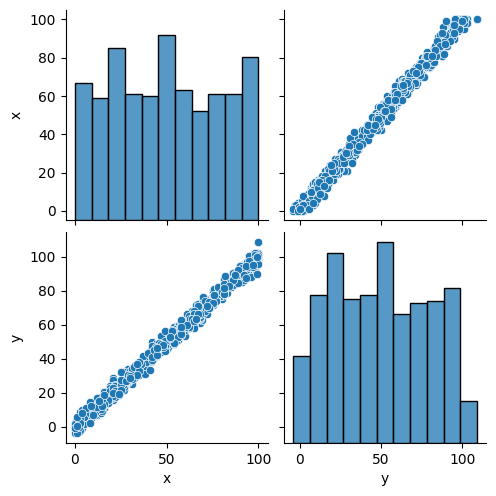

In [15]:
sns.pairplot(df)

In [18]:
# independent and dependent variable
X=df[['x']]
y=df['y']

In [20]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [21]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [24]:
# Apply linear Regression Model :
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train_scaled,y_train)

LinearRegression()

In [26]:
# printing Coefficent and Intercept
print('Coefficent:',regression.coef_)
print('Intercept:',regression.intercept_)

Coefficent: [29.06938314]
Intercept: 49.723919387307696


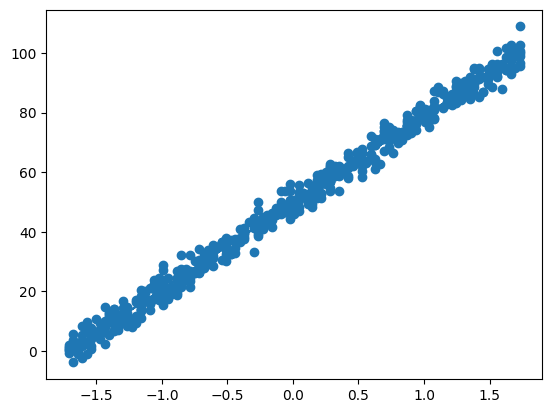

In [27]:
# Plotting training data scatter plot
plt.plot(X_train_scaled,regression.predict(X_train_scaled))
plt.scatter(X_train_scaled,y_train)

In [28]:
# Prediction
y_pred=regression.predict(X_test_scaled)

In [33]:
# Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
rmse=np.sqrt(mse)
print("MSE:",mse)
print("MAE:",mae)
print('RMSE',rmse)
print("R2:",r2)

MSE: 8.378590238617495
MAE: 2.341234624395528
RMSE 2.8945794579899675
R2: 0.9897659864942164
